## Finite-Time Lyapunov Exponents (FTLEs)

We calculate both forward (repelling) and backward (attracting) FTLEs from SatGEM-2 isopycnal velocities, using the Aviso Lagrangian 3.0 Python toolbox (https://github.com/CNES/aviso-lagrangian) and code available at https://github.com/treden/FSLE/tree/main.

In [1]:
import matplotlib.pyplot as plt
import sys
import cartopy.crs as ccrs
import os 
import xarray as xr
import numpy as np

In [2]:
# workingdir = '/g/data/jk72/mj0995'
# os.chdir(workingdir) 
# from functions import map_properties

In [3]:
workingdir = '/g/data/jk72/mj0995/fsle'
os.chdir(workingdir) 

from FSLE_functions import *

### Set the environment variable for Lagrangian 3.0 toolbox
os.environ['UDUNITS2_XML_PATH'] = '/g/data/jk72/mj0995/miniconda/g/data/v45/mj0995/Miniconda/envs/lagrangian3/share/udunits/udunits2.xml'

In [4]:
plt.rcParams['font.size'] = '12'

In [5]:
savepath = '/g/data/jk72/mj0995/figures'

### Load data

In [6]:
region = 'SEIR'

if region == 'SEIR':
    domain = [134, 166, -61, -49]
    ssh_insitu = xr.open_dataset('/g/data/jk72/mj0995/data/cmems_adt_MR.nc')
    
elif region == 'DP':
    domain = [280, 304.5, -65, -50]
    ssh_insitu = xr.open_dataset('/g/data/jk72/mj0995/data/cmems_adt_DP.nc') ## TO DO: download this file

### SatGEM with u_noise and v_noise as well as ugw and vgw
satgem = xr.open_dataset(f'/g/data/jk72/mj0995/data/satgem_{region}_on_d_noisy.nc')

#### Set parameters for FTLE computation

In [7]:
temp_dir = '_tmp/'

resolution = 0.02 ## resolution of final product (degrees)
initial_separation = 0.02 ## intial separation of particles released on grid (degrees) 
final_separation = 0.1 ## for FSLE (Finite-Sized Lyapunov Exponent)
stencil = "triplet" ## triplets of particles

In [8]:
d = 27.1
gem_sel = satgem.sel(density = d, method = 'nearest')

In [9]:
## integration/advection time
n_days = 10 
end = '2018-11-16'
t1 = pd.Timestamp(end)
t0 = t1 - np.timedelta64(n_days,'D')

#### FTLEs computed from SatGEM velocities with and without Gaussian noise

In [10]:
### Compute FTLE without Gaussian noise (using ugw and vgw)

# output_file = 'FTLE_SEIR_no_noise.nc'
# variables = {'time': 'time', 'longitude': 'longitude', 'latitude': 'latitude', 'u': 'ugw', 'v': 'vgw'}
# compute_FSLE(gem_sel, variables, t0, t1, domain, resolution, stencil, initial_separation, final_separation, output_file, temp_dir, mode = 'ftle', integration = 'backward')

In [11]:
ftle_file = 'FTLE_SEIR_no_noise.nc'
FTLE_no_noise = xr.open_dataset(ftle_file)

In [12]:
### Compute FTLE with Gaussian noise (using u_noise and v_noise)

# output_file = 'FTLE_SEIR_with_noise.nc'
# variables = {'time': 'time', 'longitude': 'longitude', 'latitude': 'latitude', 'u': 'u_noise', 'v': 'v_noise'}
# compute_FSLE(gem_sel, variables, t0, t1, domain, resolution, stencil, initial_separation, final_separation, output_file, temp_dir, mode = 'ftle',integration = 'backward')

In [13]:
ftle_file = 'FTLE_SEIR_with_noise.nc'
FTLE_with_noise = xr.open_dataset(ftle_file)

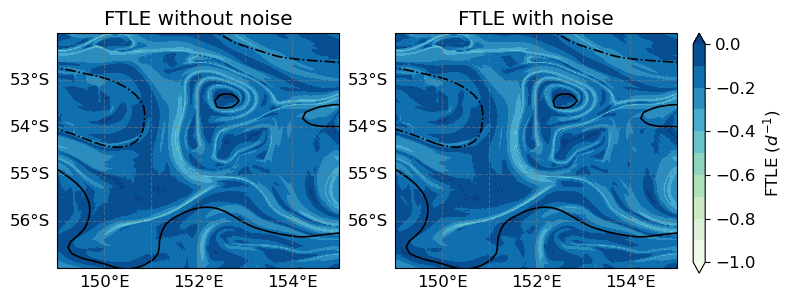

In [14]:
extent = [149, 155, -57, -52] 

fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2,
                               sharey = True, sharex = True,
                               subplot_kw={'projection': ccrs.PlateCarree()},
                               figsize=(8,5))

ax1.set_extent(extent, crs=ccrs.PlateCarree())

### Without Gaussian noise
im = ax1.contourf(FTLE_no_noise.lon, FTLE_no_noise.lat, FTLE_no_noise.lambda1.T, levels=np.arange(-1,0.1,0.1), 
                  cmap='GnBu', extend='both', transform = ccrs.PlateCarree())

# mean adt contours
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(ax = ax1, levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(ax = ax1, levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

gl = ax1.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax1.set_title('FTLE without noise')
ax1.set_ylim(extent[2], extent[3])

### With Gaussian noise
im = ax2.contourf(FTLE_with_noise.lon, FTLE_with_noise.lat, FTLE_with_noise.lambda1.T, levels=np.arange(-1,0.1,0.1), 
                  cmap='GnBu', extend='both', transform = ccrs.PlateCarree())

# mean adt contours
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(ax = ax2, levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(ax = ax2, levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

gl = ax2.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax2.set_title('FTLE with noise')
ax2.set_ylim(extent[2], extent[3])

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.48]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE ($d^{-1}$)')

#### Difference: FTLE no noise $-$ FLTE with noise

In [15]:
diff = FTLE_no_noise - FTLE_with_noise

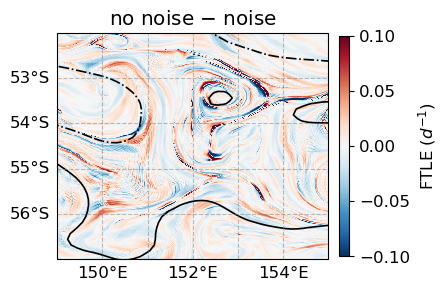

In [16]:
fig = plt.figure(figsize=(3.5,3.5))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = ax.pcolormesh(diff.lon, diff.lat, diff.lambda1.T, cmap = 'RdBu_r', vmin = -0.1, vmax = 0.1)

# mean adt contours
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
ssh_insitu.adt.sel(time = slice(t0, t1)).mean(dim = 'time').plot.contour(levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.title(u'no noise $-$ noise')
plt.ylim(extent[2], extent[3])

cbar_ax = fig.add_axes([0.93, 0.18, 0.03, 0.63]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE ($d^{-1}$)')

### Effect of integration/advection time

Changing the integration time alters the magnitude and nature of the FTLE structures. A longer integration time reveals more persistent features of the flow that can have non-local influence, while a shorter integration time highlights the transient, local dynamics that evolve rapidly.

In [17]:
d = 27.2
gem_sel = satgem.sel(density = d, method = 'nearest')

n_days = 5
end = '2018-11-08'
t1 = pd.Timestamp(end)
t0 = t1 - np.timedelta64(n_days,'D')

In [18]:
# output_file = f'FTLE_{region}_{d}_{n_days}days_{end}.nc'
# variables = {'time': 'time', 'longitude': 'longitude', 'latitude': 'latitude', 'u': 'u_noise', 'v': 'v_noise'}

# compute_FSLE(gem_sel, variables, t0, t1, domain, resolution, stencil, initial_separation, 
#              final_separation, output_file, temp_dir, mode = 'ftle',integration = 'backward')

/jobfs/147021609.gadi-pbs/ipykernel_1855461/4193841700.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


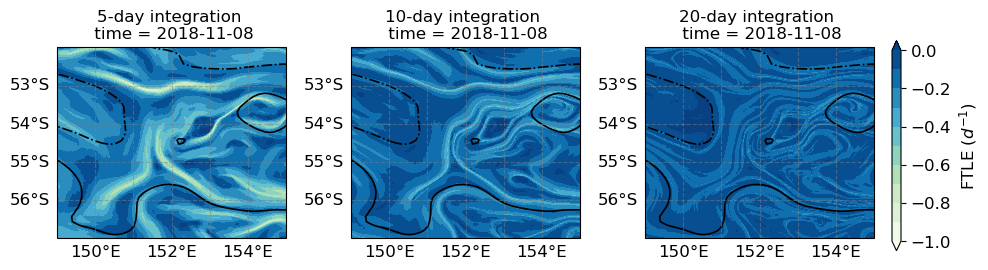

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=3, sharey = True, sharex = True, subplot_kw={'projection': ccrs.PlateCarree()},figsize=(9,6))

ax = axs.flatten()
ax[0].set_extent(extent, crs=ccrs.PlateCarree())

i = 0
for n_days in [5, 10, 20]:
    ### open file
    ftle_file = f'FTLE_{region}_{d}_{n_days}days_{end}.nc'
    FTLE = xr.open_dataset(ftle_file)

    ### plot FTLE
    im = ax[i].contourf(FTLE.lon, FTLE.lat, FTLE.lambda1.T, levels=np.arange(-1,0.1,0.1), cmap='GnBu', extend='both')

    ### mean adt contours
    ssh_insitu.adt.sel(time = end, method = 'nearest').plot.contour(ax = ax[i], levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
    ssh_insitu.adt.sel(time = end, method = 'nearest').plot.contour(ax = ax[i], levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

    gl = ax[i].gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    ax[i].set_title(f'{n_days}-day integration \n time = {end}', fontsize = 12)
    ax[i].set_ylim(extent[2], extent[3])
    i+=1

cbar_ax = fig.add_axes([1, 0.32, 0.01, 0.35]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE ($d^{-1}$)')
fig.tight_layout()

### Calculate FTLEs for each day and density level with a 10-day integration time

In [20]:
### use SatGEM velocities with noise
variables = {'time': 'time', 'longitude': 'longitude', 'latitude': 'latitude', 'u': 'u_noise', 'v': 'v_noise'}
n_days = 10

In [ ]:
def compute_ftle_on_dens(satgem, d, start, end, domain, n_days = 10, region = 'SEIR', mode = 'ftle', integration = 'backward'):
    '''Compute FTLE on density and save to the output file'''
    # set params
    initial_separation = 0.02
    final_separation = 0.1
    resolution = 0.02
    stencil = "triplet"
    
    gem_sel = satgem.sel(density = d, method = 'nearest')
    times = gem_sel.time.sel(time = slice(start, end)).data
    
    if os.path.isdir(os.path.join(region, integration, f'{d}')) == False:
        os.mkdir(os.path.join(region, integration, f'{d}'))
    
    for t1 in times:
        t0 = t1 - np.timedelta64(n_days,'D')
        end = str(t1.astype('M8[D]'))

        if mode == 'ftle':
            output_file = f'{region}/{integration}/{d}/FTLE_{region}_{end}.nc'
        else:
            output_file = f'{region}/{integration}/{d}/FSLE_{region}_{end}.nc'
            mode = None

        compute_FSLE(gem_sel, variables, t0, t1, 
                     domain, resolution, stencil, 
                     initial_separation, final_separation, 
                     output_file, temp_dir, mode = mode, integration = integration)


### Load the files and create concatenated netcdf

In [ ]:
def concat_files(satgem, d, start, end, region = 'SEIR', mode = 'ftle', integration = 'backward'):
    gem_sel = satgem.sel(density = d, method = 'nearest')
    times = gem_sel.time.sel(time = slice(start, end)).data

    files = []

    for t in times:
        end = str(t.astype('M8[D]'))

        if mode == 'ftle':
            file = f'{region}/{integration}/{d}/FTLE_{region}_{end}.nc'
        else:
            file = f'{region}/{integration}/{d}/FSLE_{region}_{end}.nc'

        da = xr.open_dataset(file)
        da['time'] = t
        da = da.assign_coords({'time': t})

        files.append(da)
    
    ds = xr.concat(files, dim = 'time')
    
    if mode == 'ftle':
        ds.to_netcdf(f'{region}/{integration}/{d}/FTLE_{region}_{d}.nc')
    else:
        ds.to_netcdf(f'{region}/{integration}/{d}/FSLE_{region}_{d}.nc')
    

In [ ]:
dens = np.arange(27.1, 27.5, 0.01)

In [ ]:
# ## Drake Passage 
# start, end = '2018-11-05', '2018-11-20'
# d = 27.1
# region = 'DP'
# domain = [280, 305, -65, -50]
# satgem = xr.open_dataset(f'/g/data/v45/mj0995/satgem_{region}_on_d_noisy.nc')

# integration = 'backward'

# compute_fsle_on_dens(satgem, d, start, end, domain, n_days = 10, region = region, mode = 'ftle', integration = integration)
# concat_files(satgem, d, start, end, region = region, mode = 'ftle', integration = integration)

In [ ]:
# ## SEIR
# start, end = '2018-11-05', '2018-11-20'
# d = 27.1
# region = 'SEIR'
# domain = [134, 166, -61, -49]
# integration = 'forward'
# satgem = xr.open_dataset(f'/g/data/v45/mj0995/satgem_{region}_on_d_noisy.nc')

# compute_fsle_on_dens(satgem, d, start, end, domain, n_days = 10, region = region, mode = 'ftle', integration = integration)
# concat_files(satgem, d, start, end, region = region, mode = 'ftle', integration = integration)

In [ ]:
# # forward integration 
# start, end = '2018-11-05', '2018-11-20'

# for d in np.arange(27.1, 27.5, 0.01):
#     d = round(d, 2)
    # compute_fsle_on_dens(satgem, d, start, end, n_days = 10, mode = 'ftle', integration = 'forward')
    # concat_files(satgem, d, start, end, mode = 'ftle', integration = 'forward')

In [ ]:
# # backward integration
# start, end = '2018-11-05', '2018-11-20'

# mode = 'ftle'

# for d in dens:
#     d = round(d, 2)
    # compute_fsle_on_dens(satgem, d, start, end, n_days = 10, mode = mode)
    # concat_files(satgem, d, start, end, mode = mode)

In [ ]:
def concat_all_files(dens, n_days = 10, mode = 'ftle', integration = 'backward'):
    files = []

    for d in dens:
        d = round(d, 2)
        
        if mode == 'ftle':
            file = integration + f'/{d}/FTLE_seir_{d}.nc'
        else:
            file = integration + f'/{d}/FSLE_seir_{d}.nc'
            
        da = xr.open_dataset(file)
        da['density'] = d
        da = da.assign_coords({'density': d})
        files.append(da)
        
    ds = xr.concat(files, dim = 'density')
    
    if mode == 'ftle':
        ds.to_netcdf(f'{integration}_FTLE_seir_{n_days}days.nc')
    else:
        ds.to_netcdf(f'{integration}_FSLE_seir_{n_days}days.nc')
        

In [ ]:
# concat_all_files(dens, n_days = 10, mode = 'ftle', integration = 'forward')
# concat_all_files(dens, n_days = 10, mode = 'fsle')

### Open dataset

In [ ]:
d = 27.1 #density level

# region = 'DP'
# extent = [295, 302, -60, -54]

region = 'SEIR'
extent = [149, 155, -57, -52]

ftle_bw = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/backward/{d}/FTLE_{region}_{d}.nc')
ftle_fw = xr.open_dataset(f'/g/data/jk72/mj0995/fsle/{region}/forward/{d}/FTLE_{region}_{d}.nc')

In [ ]:
### choose date
t = '2018-11-16'

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = ax.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(-0.8,0,0.1), cmap='GnBu', extend='both')
im2 = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both', zorder = 0)
ax.contour(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both')

# ### mean adt contours
# ssh_insitu.adt.sel(time = t, method = 'nearest').plot.contour(levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
# ssh_insitu.adt.sel(time = t, method = 'nearest').plot.contour(levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.ylim(extent[2], extent[3])
plt.title(r'$\rho$'+ f' = {d}, time = {t}')

fig.colorbar(im2, ax=ax, label = r'FTLE forward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.06)
fig.colorbar(im, ax=ax, label = r'FTLE backward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.02)

In [ ]:
# name = f'{region}_FTLE_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 600, bbox_inches='tight', pad_inches= 0.2)

### Intersection points between positive and negative FTLE (hyperbolic regions)

In [ ]:
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

im = ax.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(-0.8,0,0.1), cmap='GnBu', extend='both')
im2 = ax.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both', zorder = 0)
ax.contour(ftle_fw.lon, ftle_fw.lat, ftle_fw.lambda1.sel(time = t, method='nearest').T, levels=np.arange(0.3,0.9,0.1), cmap='PuRd', extend='both')

### intersection points (ftle_bw x ftle_fw): -0.15 contour
ax.contour(ftle_bw.lon, ftle_bw.lat, (ftle_fw.lambda1*ftle_bw.lambda1).sel(time = t, method='nearest').T, colors = 'k', levels = [-0.15], linestyles = '-')

# ### mean adt contours
# ssh_insitu.adt.sel(time = t, method = 'nearest').plot.contour(levels=[0.2], colors='k', linewidths = 1.2, linestyles = '-.', transform=ccrs.PlateCarree())
# ssh_insitu.adt.sel(time = t, method = 'nearest').plot.contour(levels=[-0.65], colors='k', linewidths = 1.2, linestyles = '-', transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.ylim(extent[2], extent[3])

fig.colorbar(im2, ax=ax, label = r'FTLE forward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.06)
fig.colorbar(im, ax=ax, label = r'FTLE backward ($d^{-1}$)', shrink = 0.5, aspect = 25, pad = 0.02)

### FTLE eigenvectors

TO DO:

- Find the difference in orientation between positive and negative FTLE ridges at the hyperbolic points.
- Are they more perpendular in MR compared to DP (more efficient particle exchange)?

In [128]:
ftle_bw.theta1.long_name

'Orientation of the eigenvectors associated to themaximum eigenvalues of Cauchy-Green strain tensor'

In [129]:
ftle_bw.lambda1.long_name

'FLE associated to the maximum eigenvalues of Cauchy-Green strain tensor'

#### Negative FTLE eigenvector orientation

In [173]:
ftle_bw_sel = ftle_bw.lambda1.sel(time = t, method = 'nearest')
ftle_bw_theta = ftle_bw.theta1.sel(time = t, method = 'nearest')

In [174]:
mask = np.ma.masked_where(ftle_bw_sel > -0.2, ftle_bw_sel)

In [175]:
ftle_bw_theta_copy = ftle_bw_theta.copy()
ftle_bw_theta_copy.data[mask.mask] = np.nan

#### Positive FTLE eigenvector orientation

In [176]:
ftle_fw_sel = ftle_fw.lambda1.sel(time = t, method = 'nearest')
ftle_fw_theta = ftle_fw.theta1.sel(time = t, method = 'nearest')

In [177]:
mask = np.ma.masked_where(ftle_fw_sel < 0.2, ftle_fw_sel)

In [178]:
ftle_fw_theta_copy = ftle_fw_theta.copy()
ftle_fw_theta_copy.data[mask.mask] = np.nan

### Plots

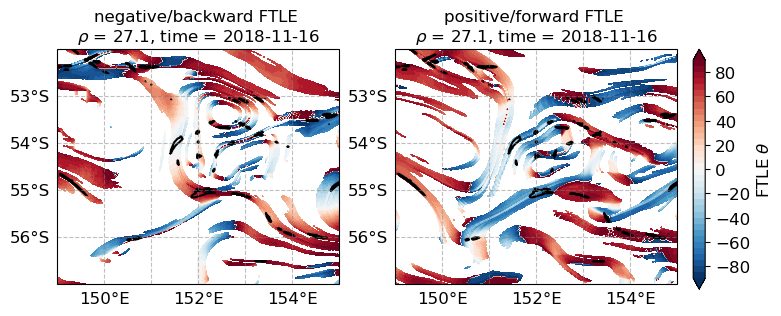

In [179]:
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, sharey = True, sharex = True,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(8,5))
ax1.set_extent(extent, crs=ccrs.PlateCarree())

im = ax1.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw_theta_copy.T, levels = np.arange(-90, 95, 5), cmap='RdBu_r', extend='both')
ax1.contour(ftle_bw.lon, ftle_bw.lat, (ftle_fw.lambda1*ftle_bw.lambda1).sel(time = t, method='nearest').T, colors = 'k', levels = [-0.15], linestyles = '-')

gl = ax1.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

im = ax2.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw_theta_copy.T, levels = np.arange(-90, 95, 5), cmap='RdBu_r', extend='both')
ax2.contour(ftle_fw.lon, ftle_fw.lat, (ftle_fw.lambda1*ftle_bw.lambda1).sel(time = t, method='nearest').T, colors = 'k', levels = [-0.15], linestyles = '-')

gl = ax2.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax1.set_ylim(extent[2], extent[3])
ax1.set_title('negative/backward FTLE \n' + r'$\rho$'+ f' = {d}, time = {t}', fontsize = 12)
ax2.set_title('positive/forward FTLE \n' + r'$\rho$'+ f' = {d}, time = {t}', fontsize = 12)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.48]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE $\theta$')

### Mask hyperbolic zones

In [168]:
hyperbolic = (ftle_fw.lambda1*ftle_bw.lambda1).sel(time = t, method='nearest')
mask = np.ma.masked_where(hyperbolic > -0.1, hyperbolic)

In [169]:
ftle_fw_theta_copy.data[mask.mask] = np.nan
ftle_bw_theta_copy.data[mask.mask] = np.nan

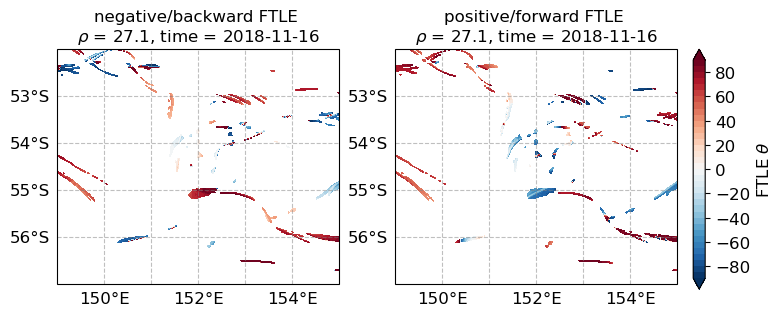

In [171]:
fig, (ax1, ax2) = plt.subplots(nrows=1,ncols=2, sharey = True, sharex = True,subplot_kw={'projection': ccrs.PlateCarree()},figsize=(8,5))
ax1.set_extent(extent, crs=ccrs.PlateCarree())

im = ax1.contourf(ftle_bw.lon, ftle_bw.lat, ftle_bw_theta_copy.T, levels = np.arange(-90, 95, 5), cmap='RdBu_r', extend='both')

gl = ax1.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

im = ax2.contourf(ftle_fw.lon, ftle_fw.lat, ftle_fw_theta_copy.T, levels = np.arange(-90, 95, 5), cmap='RdBu_r', extend='both')

gl = ax2.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax1.set_ylim(extent[2], extent[3])
ax1.set_title('negative/backward FTLE \n' + r'$\rho$'+ f' = {d}, time = {t}', fontsize = 12)
ax2.set_title('positive/forward FTLE \n' + r'$\rho$'+ f' = {d}, time = {t}', fontsize = 12)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.48]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'FTLE $\theta$')